# Importation des Libriairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage des graphiques dans le notebook
%matplotlib inline

# Paramètres d'affichage
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Charger les données

In [2]:
df = pd.read_csv("../data/creditcard.csv")

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# Comprendre la structure du dataset

In [4]:
df.shape

(6362620, 11)

# Informations générales

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


# Statistiques descriptives

In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


# Vérifier les valeurs manquantes

In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.isnull().sum().sum()

np.int64(0)

# Vérifier les doublons

In [9]:
df.duplicated().sum()
df = df.drop_duplicates()

# Étudier la variable cible

In [10]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [11]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

# Visualiser les classes

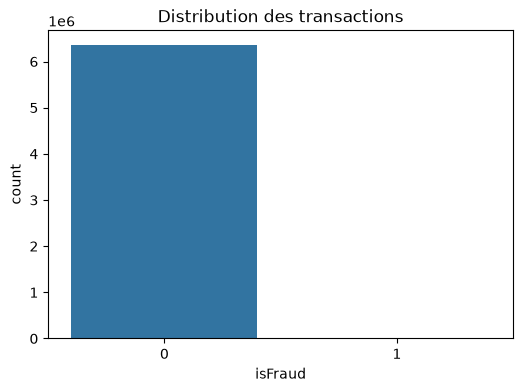

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x="isFraud", data=df)

plt.title("Distribution des transactions")
plt.show()

# Calcul du taux de fraude

In [13]:
fraud_percentage = (
    df["isFraud"].value_counts(normalize=True)[1] * 100
)

print(f"Taux de fraude : {fraud_percentage:.4f}%")

Taux de fraude : 0.1291%


# Analyse des types de transaction

In [14]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

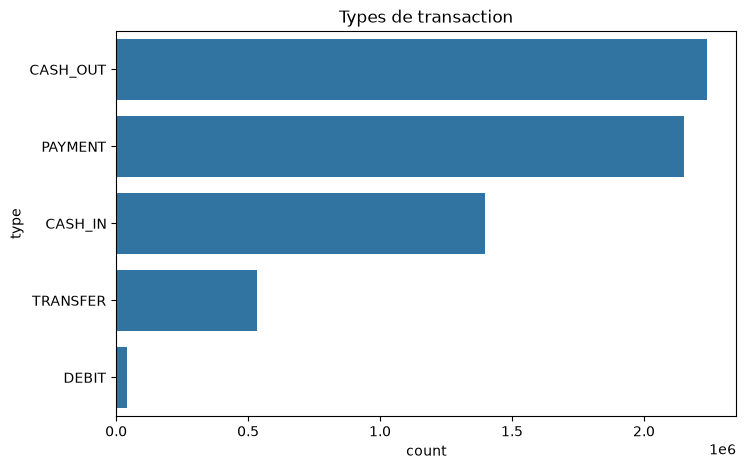

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="type",
    data=df,
    order=df["type"].value_counts().index
)

plt.title("Types de transaction")
plt.show()

# Fraudes par type de transaction

In [16]:
fraud_by_type = pd.crosstab(
    df["type"],
    df["isFraud"]
)

fraud_by_type

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


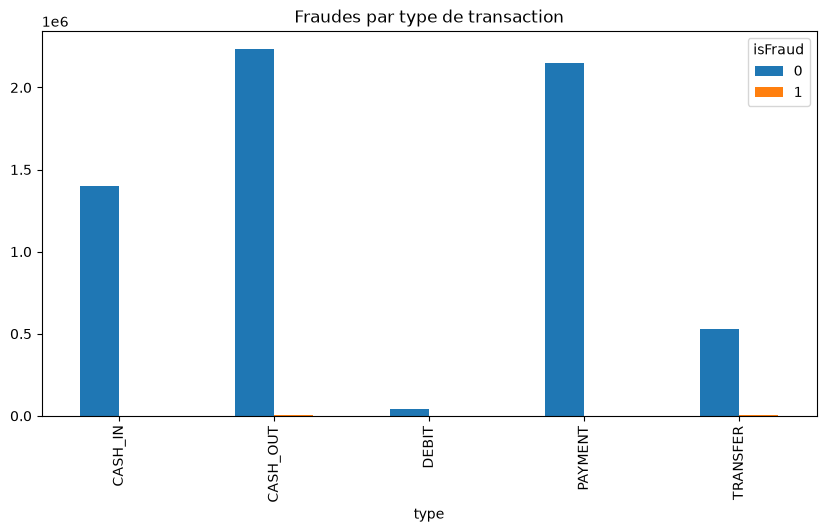

In [17]:
fraud_by_type.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Fraudes par type de transaction")
plt.show()

# Taux de fraude par type

In [18]:
fraud_rate = (
    df.groupby("type")["isFraud"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

fraud_rate

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

# Analyse du montant

In [19]:
df["amount"].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

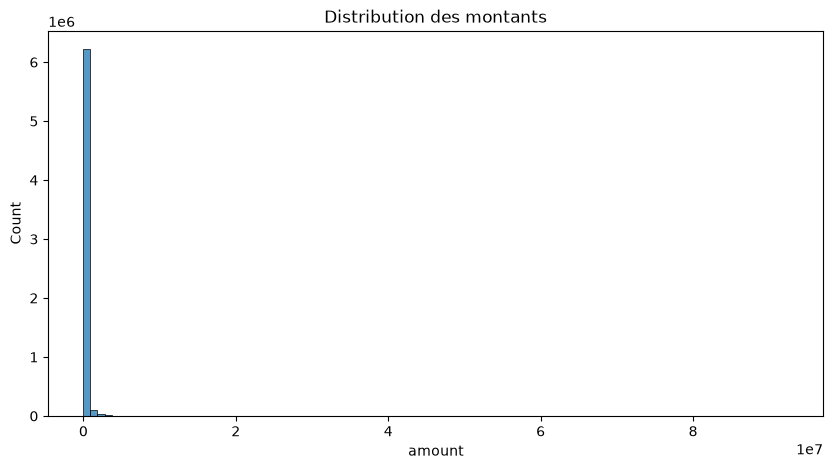

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["amount"],
    bins=100
)

plt.title("Distribution des montants")
plt.show()

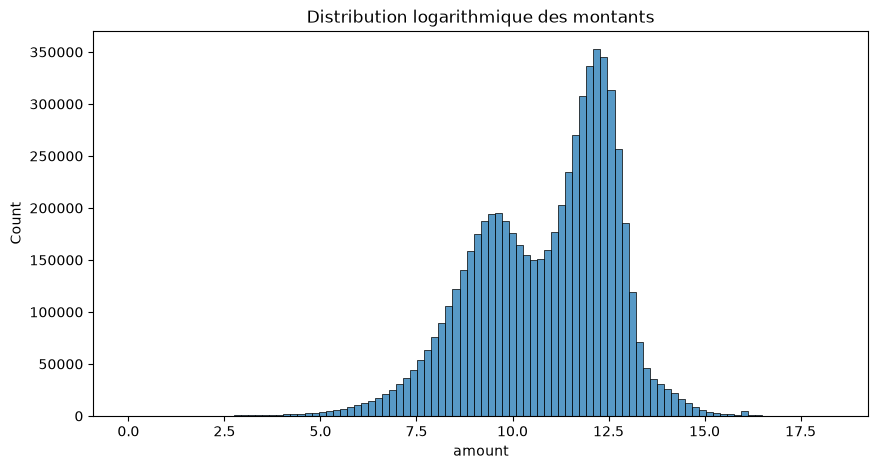

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df["amount"]),
    bins=100
)

plt.title("Distribution logarithmique des montants")
plt.show()

# Comparer les montants selon la fraude

In [22]:
sample_df = df.sample(
    100000,
    random_state=42
)

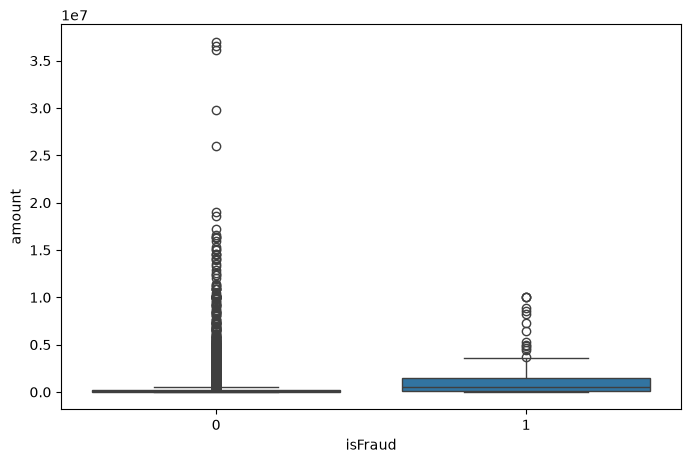

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="isFraud",
    y="amount",
    data=sample_df
)

plt.show()

# Etape du Feature Engineering

## Différence de solde côté émetteur

In [24]:
df["balance_diff_orig"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

## Différence de solde côté destinataire

In [25]:
df["balance_diff_dest"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

## Vérification

In [26]:
df[
    [
        "oldbalanceOrg",
        "newbalanceOrig",
        "balance_diff_orig",
        "oldbalanceDest",
        "newbalanceDest",
        "balance_diff_dest"
    ]
].head()

,oldbalanceOrg,newbalanceOrig,balance_diff_orig,oldbalanceDest,newbalanceDest,balance_diff_dest
0,170136.0,160296.36,9839.64,0.0,0.0,0.0
1,21249.0,19384.72,1864.28,0.0,0.0,0.0
2,181.0,0.00,181.00,0.0,0.0,0.0
3,181.0,0.00,181.00,21182.0,0.0,-21182.0
4,41554.0,29885.86,11668.14,0.0,0.0,0.0


# Transformer la variable type

In [27]:
df["type"].unique()

<ArrowStringArray>
['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN']
Length: 5, dtype: str

## Encodage One-Hot

In [28]:
df = pd.get_dummies(
    df,
    columns=["type"],
    drop_first=True
)

In [29]:
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,False,False,True,False
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,False,False,True,False
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,False,False,False,True
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0,True,False,False,False
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,False,False,True,False


## Supprimer les identifiants

In [30]:
df.drop(
    columns=["nameOrig", "nameDest"],
    inplace=True
)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 14 columns):
 #   Column             Dtype  
---  ------             -----  
 0   step               int64  
 1   amount             float64
 2   oldbalanceOrg      float64
 3   newbalanceOrig     float64
 4   oldbalanceDest     float64
 5   newbalanceDest     float64
 6   isFraud            int64  
 7   isFlaggedFraud     int64  
 8   balance_diff_orig  float64
 9   balance_diff_dest  float64
 10  type_CASH_OUT      bool   
 11  type_DEBIT         bool   
 12  type_PAYMENT       bool   
 13  type_TRANSFER      bool   
dtypes: bool(4), float64(7), int64(3)
memory usage: 509.7 MB


# Préparer X et y

In [32]:
y = df["isFraud"]

In [33]:
X = df.drop(
    columns=["isFraud"]
)

In [34]:
print(X.shape)
print(y.shape)

(6362620, 13)
(6362620,)


### Séparation Train/Test

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
print(X_train.shape)
print(X_test.shape)

(5090096, 13)
(1272524, 13)


# Gestion du déséquilibre des classes

In [37]:
y_train.value_counts()

isFraud
0    5083526
1       6570
Name: count, dtype: int64

In [38]:
y.value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

# Appliquer SMOTE

In [39]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [40]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(
    X_train,
    y_train
)

In [41]:
y_train_res.value_counts()

isFraud
0    5083526
1    5083526
Name: count, dtype: int64

# Premier modèle (Baseline)

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_res,
    y_train_res
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

# Prédictions

In [43]:
y_pred = rf.predict(X_test)

# Évaluation

In [44]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.74      0.97      0.84      1643

    accuracy                           1.00   1272524
   macro avg       0.87      0.98      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



# Matrice de confusion

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[1270316,     565],
       [     55,    1588]])

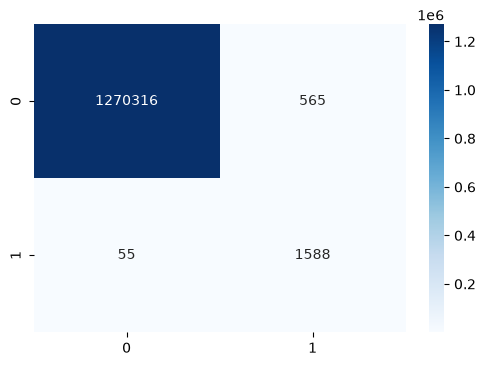

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.show()

# Importance des variables

In [47]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
})

In [48]:
importance.sort_values(
    by="importance",
    ascending=False
).head(15)

,feature,importance
7,balance_diff_orig,0.363076
2,oldbalanceOrg,0.153465
1,amount,0.099644
3,newbalanceOrig,0.098708
8,balance_diff_dest,0.067064
12,type_TRANSFER,0.058255
11,type_PAYMENT,0.037387
5,newbalanceDest,0.033237
0,step,0.032715
9,type_CASH_OUT,0.030908


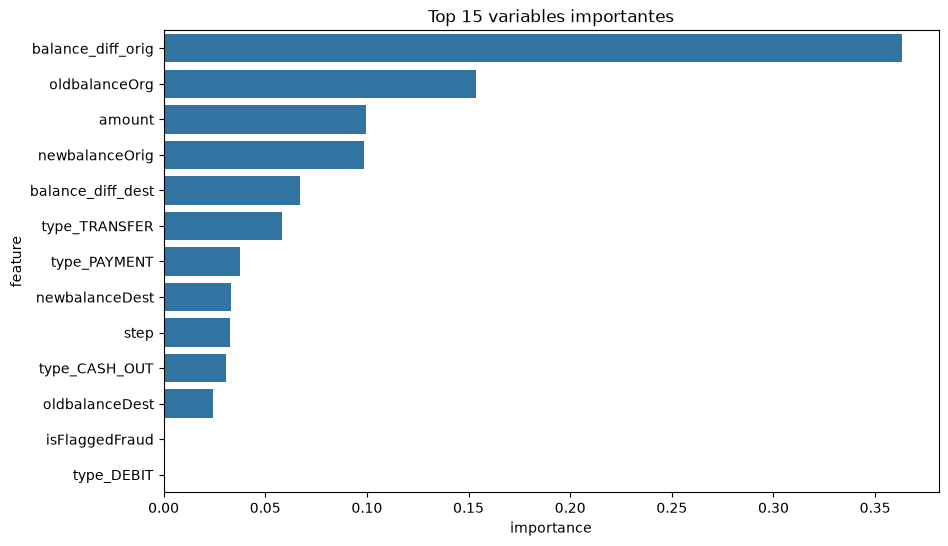

In [49]:
top = (
    importance
    .sort_values("importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top,
    x="importance",
    y="feature"
)

plt.title("Top 15 variables importantes")
plt.show()